Capstone Two: Modeling – Time Series Electricity Demand Forecasting

The objective of this modeling phase is to develop and evaluate multiple regression models to predict hourly electricity demand (demand_mw) in the U.S. Lower 48.

Because this dataset represents time-series data, a chronological train-test split is applied to prevent data leakage and simulate real-world forecasting conditions.

Multiple regression models will be trained and compared using appropriate evaluation metrics to identify the best-performing model.

In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

1. Load and Prepare Dataset

The cleaned hourly electricity dataset is loaded and sorted chronologically to ensure proper time-series modeling.

In [3]:
df = pd.read_csv("us_lower48_hourly_clean.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

# Sort chronologically
df = df.sort_values("datetime").reset_index(drop=True)

df.head()

,datetime,demand_mw,coal_mw,gas_mw,nuclear_mw,hydro_mw,solar_mw,wind_mw,petroleum_mw,other_mw
0,2015-07-01 05:00:00+00:00,162827,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-07-01 06:00:00+00:00,335153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-07-01 07:00:00+00:00,333837,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-07-01 08:00:00+00:00,398386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-07-01 09:00:00+00:00,388954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


2. Feature Engineering – Time-Based Features

Since electricity demand is highly time-dependent, additional temporal features are extracted from the datetime column.

In [4]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

3. Define Target and Feature Matrix

The response variable is demand_mw. All other generation sources and engineered time features are used as predictors.

In [5]:
target_col = "demand_mw"

X = df.drop(columns=[target_col, "datetime"])
y = df[target_col]

X.shape, y.shape

((58936, 12), (58936,))

4. Chronological Train–Test Split

To simulate forecasting, the first 80% of observations are used for training and the remaining 20% are reserved for testing.

In [6]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (47148, 12)
Testing size: (11788, 12)


5. Verify Chronological Integrity

The final training timestamp should occur before the first testing timestamp.

In [7]:
print("Last training date:", df.iloc[:split_index]["datetime"].max())
print("First testing date:", df.iloc[split_index:]["datetime"].min())

Last training date: 2020-11-15 16:00:00+00:00
First testing date: 2020-11-15 17:00:00+00:00


6. Define Evaluation Function

Models are evaluated using:

Mean Absolute Error (MAE)

Root Mean Squared Error (RMSE)

R² Score

In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return mae, rmse, r2

7. Model 1 – Linear Regression (Baseline)

Linear Regression serves as a baseline model to establish initial performance.

In [9]:
lr = LinearRegression()

lr_mae, lr_rmse, lr_r2 = evaluate_model(lr, X_train, X_test, y_train, y_test)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 21538.154680241852
RMSE: 27135.52426096984
R2: 0.8409738291694537


8. Model 2 – Random Forest Regressor

Random Forest captures nonlinear relationships and feature interactions.

In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(rf, X_train, X_test, y_train, y_test)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 12286.45276048902
RMSE: 16104.615766844716
R2: 0.9439864750530425


9. Model 3 – Gradient Boosting Regressor

Gradient Boosting improves predictions sequentially by correcting prior errors.

In [11]:
gbr = GradientBoostingRegressor(random_state=42)

gbr_mae, gbr_rmse, gbr_r2 = evaluate_model(gbr, X_train, X_test, y_train, y_test)

print("Gradient Boosting")
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2:", gbr_r2)

Gradient Boosting
MAE: 14398.419345234
RMSE: 18573.454139644815
R2: 0.9254963543925446


10. Time-Series Cross Validation

To ensure robustness, TimeSeriesSplit is used instead of traditional K-fold cross-validation.

In [12]:
tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')
    print(f"{name} TimeSeries CV R2 Mean:", scores.mean())

Linear Regression TimeSeries CV R2 Mean: 0.2753947356603657
Random Forest TimeSeries CV R2 Mean: 0.8170209327587985
Gradient Boosting TimeSeries CV R2 Mean: 0.8158901460056098


11. Model Comparison Summary

All models are compared using evaluation metrics to determine the best-performing approach.

In [13]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_mae, rf_mae, gbr_mae],
    "RMSE": [lr_rmse, rf_rmse, gbr_rmse],
    "R2": [lr_r2, rf_r2, gbr_r2]
})

results.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
1,Random Forest,12286.452760,16104.615767,0.943986
2,Gradient Boosting,14398.419345,18573.454140,0.925496
0,Linear Regression,21538.154680,27135.524261,0.840974


Final Model Selection

Based on test-set performance and time-series cross-validation results, Random Forest Regressor is selected as the final model for this project.

This model achieved the highest R² (0.944) and the lowest RMSE and MAE among the tested models, indicating the strongest predictive performance while maintaining generalization across time.

In [14]:
best_row = results.sort_values(by="R2", ascending=False).iloc[0]
best_model_name = best_row["Model"]

print("Best Model:", best_model_name)
best_row

Best Model: Random Forest


Model    Random Forest
MAE        12286.45276
RMSE      16104.615767
R2            0.943986
Name: 1, dtype: object

Conclusion

In this modeling phase:

A chronological train-test split was applied to prevent data leakage.

Three regression models were trained and evaluated: Linear Regression, Random Forest, and Gradient Boosting.

TimeSeriesSplit cross-validation was used to ensure robust validation across time.

Based on evaluation metrics (MAE, RMSE, and R²), Random Forest Regressor was selected as the final model.

The Random Forest model achieved the highest R² (0.944) and the lowest error metrics, demonstrating the strongest predictive performance for hourly electricity demand forecasting.

This model will be used as the final predictive model for this project.

## Model Visualization and Evaluation
The following visualizations illustrate the behavior of electricity demand and evaluate the performance of the final Random Forest model.

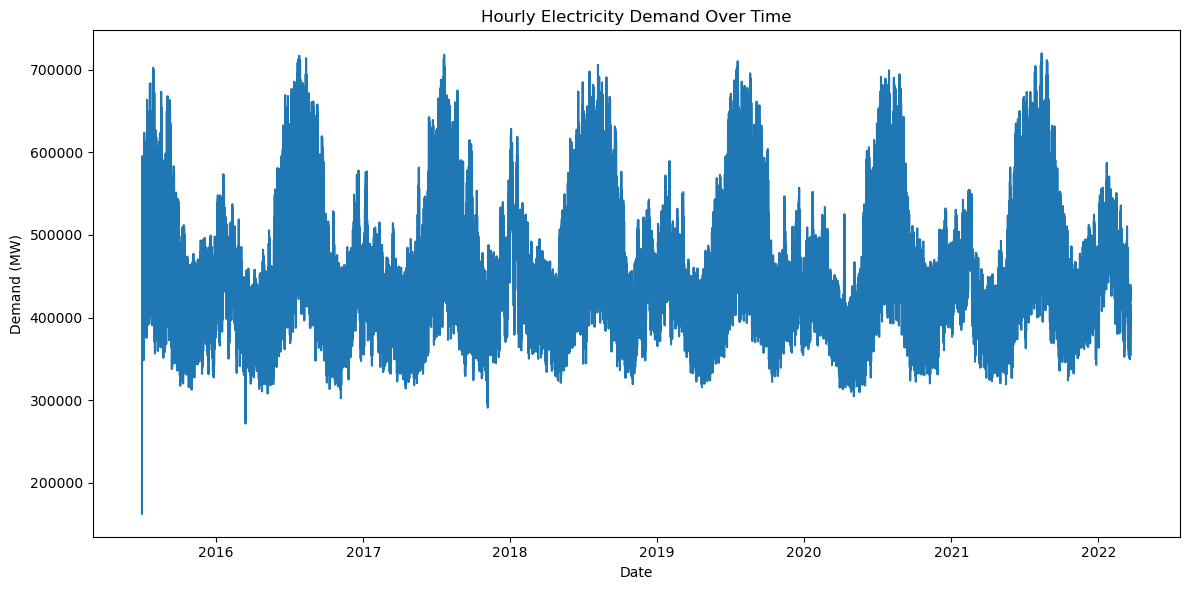

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["datetime"], df["demand_mw"])
plt.title("Hourly Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.tight_layout()

plt.savefig("demand_over_time.png")
plt.show()

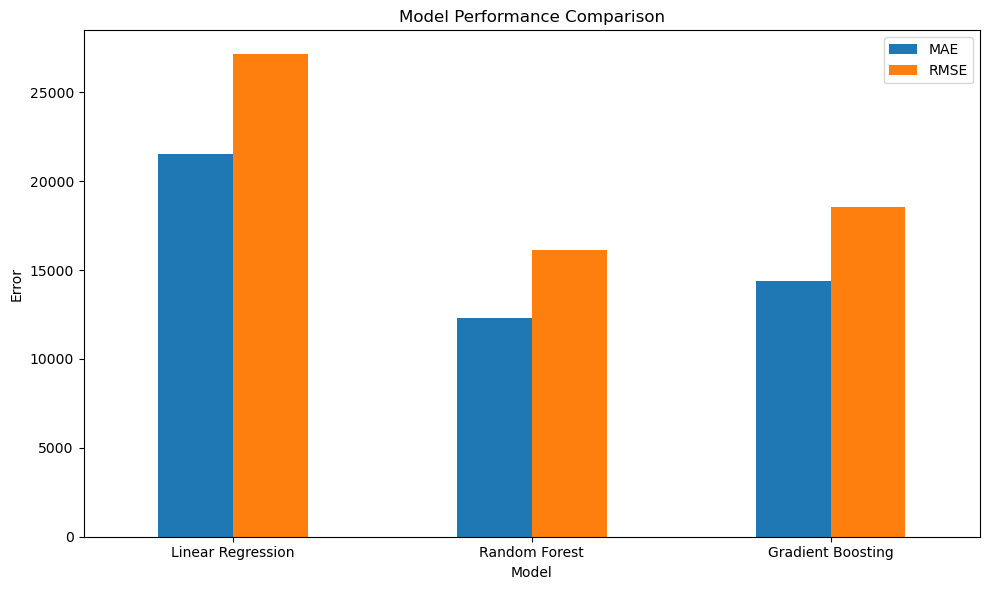

In [16]:
results.set_index("Model")[["MAE","RMSE"]].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("model_comparison.png")

plt.show()

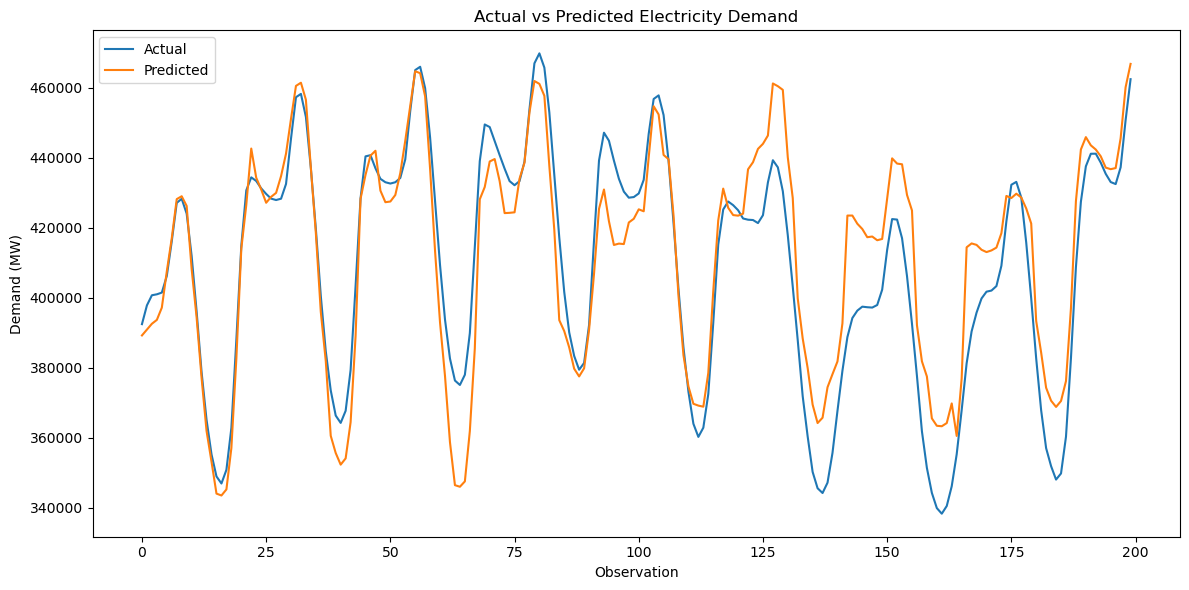

In [17]:
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Observation")
plt.ylabel("Demand (MW)")
plt.legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted.png")

plt.show()

In [18]:
results.to_csv("model_metrics.csv", index=False)